# **Multivariate Customer Segmentation for E-Commerce**


**Dataset:** customer-level purchase counts per brand (Cust_ID, Gender, Orders, ~35 brand columns)

**Goal:** Produce a portfolio-quality statistical analysis using multivariate techniques:
- PCA, Factor Analysis (KMO, Bartlett, Varimax), Clustering, LDA (discriminant analysis), CCA
- Hypothesis tests and segment-level business recommendations
- Clean storytelling, reproducible code, and interpretability for stakeholders




# **0. Install required packages if missing**

In [1]:
import sys, subprocess
reqs = ["pandas","numpy","matplotlib","seaborn","scikit-learn","factor_analyzer","scipy","statsmodels","tabulate"]
for p in reqs:
    try:
        __import__(p)
    except Exception:
        print(f"Installing {p} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", p, "--quiet"])


Installing scikit-learn ...
Installing factor_analyzer ...


# **1. Imports and display settings**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import CCA
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity
import scipy.stats as stats
from tabulate import tabulate
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


# **2. Load the data**


In [3]:
df = pd.read_csv("/content/e-commerce-data.csv", low_memory=False)
print("Shape:", df.shape)
df.head()


Shape: (30000, 38)


,Cust_ID,Gender,Orders,Jordan,Gatorade,Samsung,Asus,Udis,Mondelez International,Wrangler,Vans,Fila,Brooks,H&M,Dairy Queen,Fendi,Hewlett Packard,Pladis,Asics,Siemens,J.M. Smucker,Pop Chips,Juniper,Huawei,Compaq,IBM,Burberry,Mi,LG,Dior,Scabal,Tommy Hilfiger,Hollister,Forever 21,Colavita,Microsoft,Jiffy mix,Kraft
0,1,M,7,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,F,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2,2,1,0,0,0,6,4,0,1,0,0,0,0,0,0,0,0
2,3,M,7,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,F,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,NaN,10,0,0,0,0,0,0,0,0,0,0,0,1,0,0,5,1,0,3,0,1,0,0,0,1,0,0,0,2,0,0,0,0,0,1,1


# **Quick inspection**

We look at columns, missingness, types and the first few rows to understand structure.

# **3. Quick dataset diagnostics**


In [4]:
print("Columns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nSample rows:")
display(df.head(6))


Columns: ['Cust_ID', 'Gender', 'Orders', 'Jordan', 'Gatorade', 'Samsung', 'Asus', 'Udis', 'Mondelez International', 'Wrangler', 'Vans', 'Fila', 'Brooks', 'H&M', 'Dairy Queen', 'Fendi', 'Hewlett Packard', 'Pladis', 'Asics', 'Siemens', 'J.M. Smucker', 'Pop Chips', 'Juniper', 'Huawei', 'Compaq', 'IBM', 'Burberry', 'Mi', 'LG', 'Dior', 'Scabal', 'Tommy Hilfiger', 'Hollister', 'Forever 21', 'Colavita', 'Microsoft', 'Jiffy mix', 'Kraft']

Dtypes:
 Cust_ID                    int64
Gender                    object
Orders                     int64
Jordan                     int64
Gatorade                   int64
Samsung                    int64
Asus                       int64
Udis                       int64
Mondelez International     int64
Wrangler                   int64
Vans                       int64
Fila                       int64
Brooks                     int64
H&M                        int64
Dairy Queen                int64
Fendi                      int64
Hewlett Packard            

,Cust_ID,Gender,Orders,Jordan,Gatorade,Samsung,Asus,Udis,Mondelez International,Wrangler,Vans,Fila,Brooks,H&M,Dairy Queen,Fendi,Hewlett Packard,Pladis,Asics,Siemens,J.M. Smucker,Pop Chips,Juniper,Huawei,Compaq,IBM,Burberry,Mi,LG,Dior,Scabal,Tommy Hilfiger,Hollister,Forever 21,Colavita,Microsoft,Jiffy mix,Kraft
0,1,M,7,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,F,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2,2,1,0,0,0,6,4,0,1,0,0,0,0,0,0,0,0
2,3,M,7,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,F,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,NaN,10,0,0,0,0,0,0,0,0,0,0,0,1,0,0,5,1,0,3,0,1,0,0,0,1,0,0,0,2,0,0,0,0,0,1,1
5,6,F,4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,2,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0


# **Data cleaning & assumptions**
- `Cust_ID` is unique identifier per customer
- `Orders` = number of orders (use as Frequency)
- Brand columns are integer counts of purchases for that brand by the customer
- We'll verify that sum of brand counts is consistent with Orders (or at least correlated)


In [5]:
# 4. Identify columns
cols = list(df.columns)
id_col = "Cust_ID"
gender_col = None
orders_col = None
brand_cols = []

# heuristics
for c in cols:
    lc = c.lower()
    if lc in ("cust_id","customerid","customer_id"):
        id_col = c
    if lc in ("gender","sex"):
        gender_col = c
    if lc in ("orders","order_count","ordercount","num_orders"):
        orders_col = c

# brands: all numeric columns excluding id/orders but keep gender out
for c in cols:
    if c == id_col or c == gender_col or c == orders_col:
        continue
    # consider numeric (int) columns as brand columns
    if np.issubdtype(df[c].dtype, np.number):
        brand_cols.append(c)

print("Detected id_col:", id_col)
print("Detected gender_col:", gender_col)
print("Detected orders_col:", orders_col)
print("Number of brand columns detected:", len(brand_cols))
print("Sample brand columns:", brand_cols[:10])


Detected id_col: Cust_ID
Detected gender_col: Gender
Detected orders_col: Orders
Number of brand columns detected: 35
Sample brand columns: ['Jordan', 'Gatorade', 'Samsung', 'Asus', 'Udis', 'Mondelez International', 'Wrangler', 'Vans', 'Fila', 'Brooks']


# **5. Basic checks and derived features**


In [6]:
# Fill NaNs in brand cols with 0 (assume missing = no purchase)
df[brand_cols] = df[brand_cols].fillna(0).astype(int)

# Confirm orders vs sum of brands
df["brand_sum"] = df[brand_cols].sum(axis=1)
if orders_col:
    print("Orders column exists; show comparison summary:")
    print(df[[orders_col,"brand_sum"]].describe().T)
    # correlation
    corr = df[orders_col].corr(df["brand_sum"])
    print("Correlation between Orders and brand_sum:", corr)
else:
    print("No Orders column detected; using brand_sum as purchase frequency proxy.")
    orders_col = "brand_sum"
    df[orders_col] = df["brand_sum"]

# Quick distribution of brand_sum
display(df[[id_col, gender_col, orders_col, "brand_sum"]].head())


Orders column exists; show comparison summary:
             count      mean       std  min  25%  50%  75%    max
Orders     30000.0  4.169800  3.590311  0.0  1.0  4.0  7.0   12.0
brand_sum  30000.0  6.871433  6.782249  0.0  3.0  5.0  9.0  160.0
Correlation between Orders and brand_sum: 0.037756886356404284


,Cust_ID,Gender,Orders,brand_sum
0,1,M,7,2
1,2,F,0,18
2,3,M,7,5
3,4,F,0,2
4,5,NaN,10,16


# **Feature engineering**
- `brand_sum` already computed (total purchased items across brands)
- Create `purchase_diversity` = number of different brands purchased (non-zero brand columns)
- Create category aggregates (Electronics, Apparel, Food/CPG, Others) via keyword mapping to enable CCA and interpretable factor analysis


In [7]:
# 6. Feature engineering: diversity and categories
# purchase diversity (count of brands with >0 purchases)
df["purchase_diversity"] = (df[brand_cols] > 0).sum(axis=1)

# Create brand category mapping heuristically by keyword matching
# This mapping is conservative; manually adjust if you know exact categories
electronics_keywords = ["samsung","asus","huawei","mi","lg","compaq","ibm","microsoft"]
apparel_keywords = ["wrangler","vans","fila","brooks","h&m","tommy","hollister","burberry","forever","dior","scabal","jord"]
food_keywords = ["kraft","jiffy","colavita","udis","gatorade","mondelez","dairy","colavita","jiffy mix"]

def categorize_brand(b):
    b_low = b.lower()
    if any(k in b_low for k in electronics_keywords):
        return "Electronics"
    if any(k in b_low for k in apparel_keywords):
        return "Apparel"
    if any(k in b_low for k in food_keywords):
        return "Food"
    return "Other"

brand_cat = {b: categorize_brand(b) for b in brand_cols}
# Create category aggregates per customer
categories = sorted(list(set(brand_cat.values())))
for cat in categories:
    cols_for_cat = [b for b, c in brand_cat.items() if c == cat]
    df[f"cat_{cat}"] = df[cols_for_cat].sum(axis=1) if cols_for_cat else 0

print("Categories created:", categories)
display(df[[id_col, orders_col, "brand_sum", "purchase_diversity"] + [f"cat_{c}" for c in categories]].head())


Categories created: ['Apparel', 'Electronics', 'Food', 'Other']


,Cust_ID,Orders,brand_sum,purchase_diversity,cat_Apparel,cat_Electronics,cat_Food,cat_Other
0,1,7,2,1,2,0,0,0
1,2,0,18,8,8,4,1,5
2,3,7,5,4,0,1,1,3
3,4,0,2,2,1,0,0,1
4,5,10,16,9,3,1,2,10


# **Exploratory Data Analysis (EDA)**
- Distribution of Orders / brand_sum and purchase_diversity
- Top brands (by total purchases)
- Correlation heatmap of top brands


# **7. EDA plots**


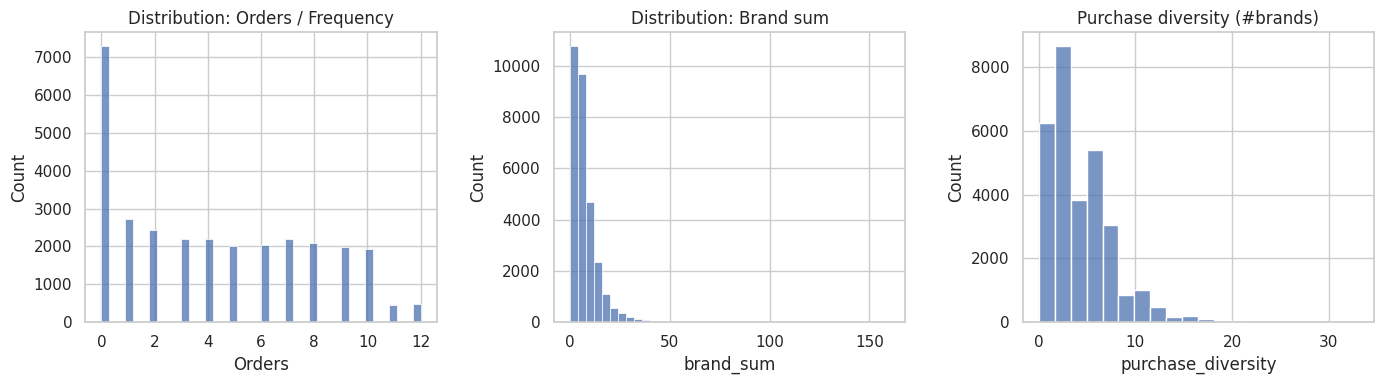

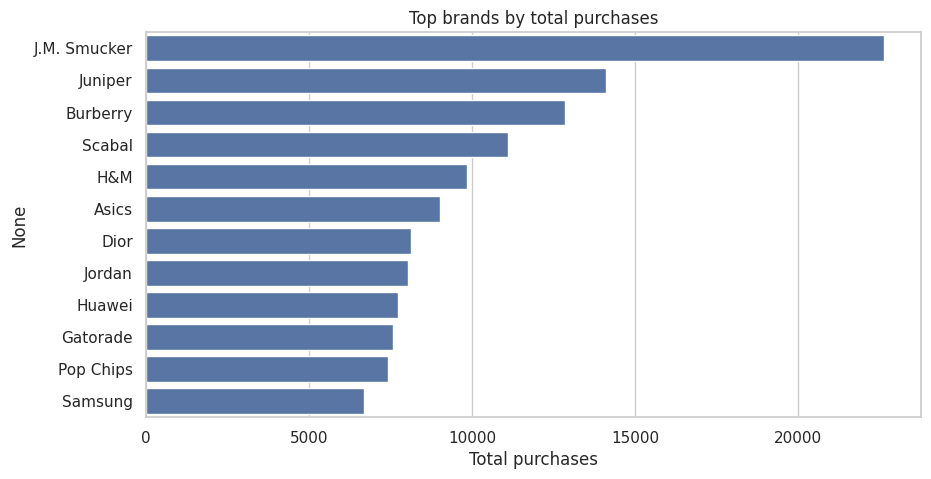

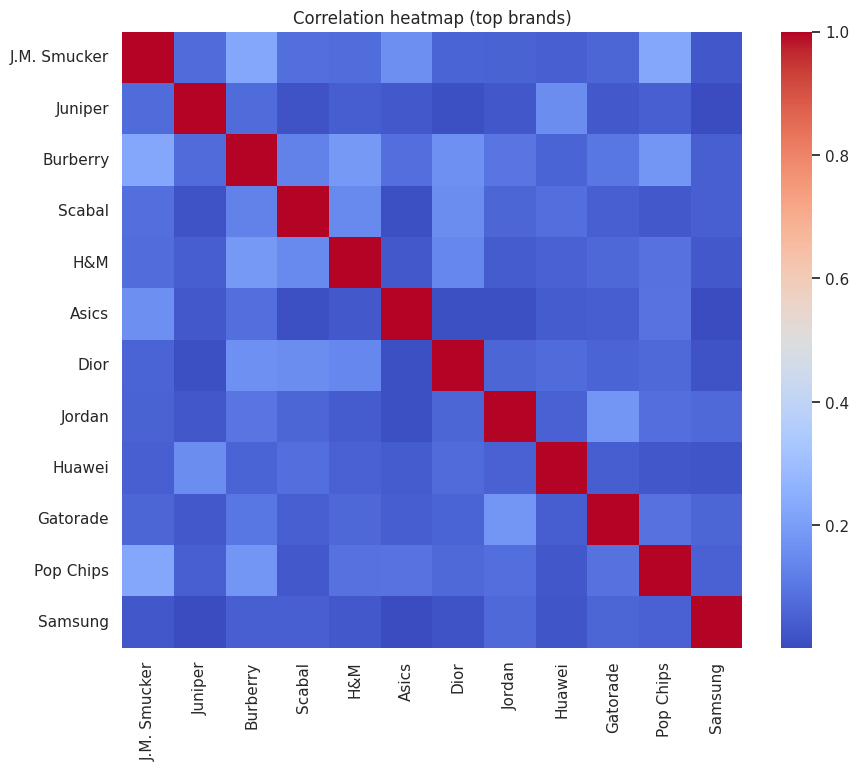

In [8]:
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
sns.histplot(df[orders_col], bins=40, kde=False)
plt.title("Distribution: Orders / Frequency")

plt.subplot(1,3,2)
sns.histplot(df["brand_sum"], bins=40)
plt.title("Distribution: Brand sum")

plt.subplot(1,3,3)
sns.histplot(df["purchase_diversity"], bins=20)
plt.title("Purchase diversity (#brands)")
plt.tight_layout(); plt.show()

# Top brands
brand_totals = df[brand_cols].sum().sort_values(ascending=False)
top_brands = brand_totals.head(12)
plt.figure(figsize=(10,5))
sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title("Top brands by total purchases")
plt.xlabel("Total purchases")
plt.show()

# Correlation heatmap for top brands
top = list(top_brands.index)
corr_top = df[top].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_top, annot=False, cmap="coolwarm")
plt.title("Correlation heatmap (top brands)")
plt.show()


# **Principal Component Analysis (PCA) on brand purchase matrix**
We standardize across customers and run PCA to reduce dimensionality and visualize main axes of variation.


# **8. PCA on brand matrix (use log1p transform to reduce skewness)**


Explained variance (first 6 PCs): [0.0944 0.0486 0.0456 0.0414 0.0402 0.0346]


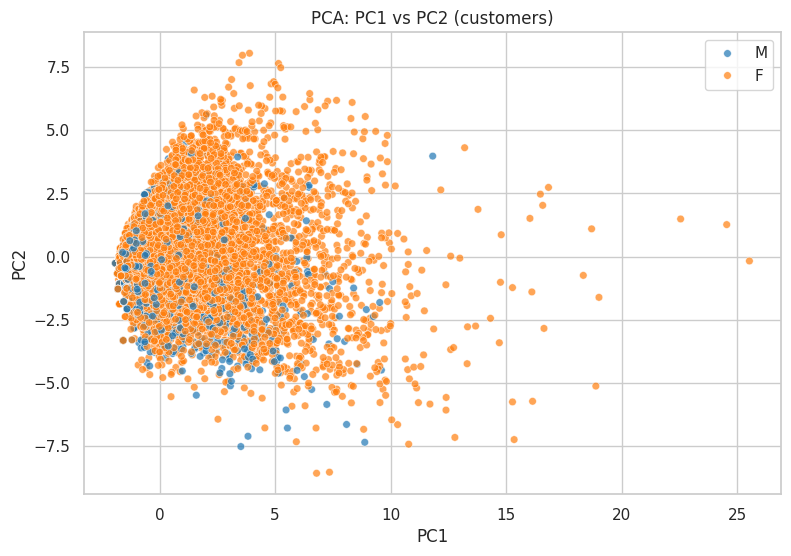

Top positive loadings PC1:


,PC1
Burberry,0.352205
Dairy Queen,0.308581
Pladis,0.300269
Tommy Hilfiger,0.231468
Kraft,0.219478
J.M. Smucker,0.214520
Pop Chips,0.203321
LG,0.197584
Jiffy mix,0.195335
Colavita,0.193333


Top positive loadings PC2:


,PC2
Hollister,0.303917
Forever 21,0.273229
Jordan,0.260601
Scabal,0.257489
Udis,0.237957
Gatorade,0.213581
Wrangler,0.191508
Asus,0.190698
Vans,0.163568
Samsung,0.147365


In [9]:
X_brands = np.log1p(df[brand_cols])  # transform
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_brands)

pca = PCA(n_components=6, random_state=42)
pcs = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print("Explained variance (first 6 PCs):", np.round(explained,4))
pc_df = pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
pc_df[id_col] = df[id_col].values
pc_df[gender_col] = df[gender_col].values if gender_col in df.columns else None

# Scatter PC1 vs PC2
plt.figure(figsize=(9,6))
sns.scatterplot(x=pc_df["PC1"], y=pc_df["PC2"], hue=df[gender_col] if gender_col else None, palette="tab10", s=30, alpha=0.7)
plt.title("PCA: PC1 vs PC2 (customers)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(loc="best")
plt.show()

# Show top loadings for PC1 and PC2
loadings = pd.DataFrame(pca.components_.T, index=brand_cols, columns=[f"PC{i+1}" for i in range(pca.n_components_)])
print("Top positive loadings PC1:")
display(loadings["PC1"].sort_values(ascending=False).head(10))
print("Top positive loadings PC2:")
display(loadings["PC2"].sort_values(ascending=False).head(10))


# **Factor Analysis (EFA) with KMO, Bartlett, Varimax on brand features**
We test sampling adequacy (KMO) and sphericity (Bartlett), then extract interpretable factors via Varimax rotation.


# **9. KMO and Bartlett for brand matrix**


In [10]:
# Use the log1p-scaled brand matrix prepared earlier (X_scaled)
kmo_all, kmo_model = calculate_kmo(X_scaled)
chi_square_value, bartlett_p = calculate_bartlett_sphericity(X_scaled)
print("KMO overall:", round(kmo_model,3))
print("Bartlett's test p-value:", round(bartlett_p,6))

# Decide number of factors by eigenvalues > 1 rule
eig_vals, eig_vecs = np.linalg.eig(np.cov(X_scaled.T))
eig_vals_sorted = np.sort(eig_vals)[::-1]
print("Eigenvalues (top 10):", np.round(eig_vals_sorted[:10],3))

n_factors = sum(eig_vals_sorted > 1)
if n_factors < 1:
    n_factors = min(3, X_scaled.shape[1])
print("Suggested n_factors (Kaiser's rule):", n_factors)

# Run FactorAnalyzer with Varimax
fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
fa.fit(X_scaled)
loadings = pd.DataFrame(fa.loadings_, index=brand_cols, columns=[f"Factor{i+1}" for i in range(n_factors)])
print("Factor loadings (rounded):")
display(loadings.round(3))

# Show sorted loadings per factor (top contributors)
for i in range(n_factors):
    print(f"\nTop contributors Factor {i+1}:")
    display(loadings.iloc[:,i].abs().sort_values(ascending=False).head(10))


KMO overall: 0.768
Bartlett's test p-value: 0.0
Eigenvalues (top 10): [3.306 1.702 1.595 1.451 1.406 1.21  1.123 1.073 1.035 1.016]
Suggested n_factors (Kaiser's rule): 10
Factor loadings (rounded):


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
Jordan,0.037,-0.005,-0.003,0.072,0.382,0.023,0.040,0.300,0.031,0.017
Gatorade,0.030,0.035,0.019,0.083,0.487,0.023,0.016,0.053,0.051,0.043
Samsung,0.011,-0.009,0.016,0.050,0.167,0.007,0.087,0.078,0.027,-0.022
Asus,0.018,0.010,0.001,0.051,0.127,0.013,0.003,0.322,0.027,0.018
Udis,-0.007,-0.024,0.027,0.067,0.068,0.020,0.025,0.418,0.035,-0.004
Mondelez International,0.032,0.001,0.039,0.175,0.045,0.021,0.115,0.075,-0.010,-0.030
Wrangler,0.013,-0.012,0.087,0.135,0.127,0.018,0.009,0.015,0.129,-0.033
Vans,0.040,-0.007,-0.005,-0.020,0.414,0.022,0.038,0.023,0.039,-0.022
Fila,0.018,0.006,0.033,0.031,0.055,0.019,0.080,0.046,-0.030,-0.016
Brooks,0.138,-0.005,0.026,0.002,0.298,0.001,0.130,0.233,-0.049,0.040



Top contributors Factor 1:


,Factor1
Dairy Queen,0.583402
Pladis,0.573893
Burberry,0.481425
Kraft,0.435824
Jiffy mix,0.350260
Colavita,0.304509
Tommy Hilfiger,0.215484
LG,0.215227
Pop Chips,0.157196
Microsoft,0.148167



Top contributors Factor 2:


...

,Factor8
Udis,0.418247
Asus,0.321982
Jordan,0.300365
Brooks,0.232573
Scabal,0.101888
Samsung,0.078371
Mondelez International,0.075323
Gatorade,0.052718
Fila,0.046276
Pladis,0.046049



Top contributors Factor 9:


,Factor9
H&M,0.335652
Fendi,0.327431
Burberry,0.190900
Hewlett Packard,0.181743
LG,0.180522
Dairy Queen,0.179663
Pop Chips,0.129408
Wrangler,0.128959
Dior,0.095872
Hollister,0.071251



Top contributors Factor 10:


,Factor10
Colavita,0.325892
Microsoft,0.263602
Juniper,0.187421
J.M. Smucker,0.116886
Jiffy mix,0.108118
LG,0.101717
Kraft,0.095637
H&M,0.092124
Pop Chips,0.068639
Mi,0.050016


# **Interpretation guidance:**  
Look at strong positive loadings (>= ~0.4) per factor to infer behavioral dimensions (e.g., Electronics affinity, Apparel lover, Food buyer).


# **10. Factor scores per customer and add to dataframe**


In [11]:
factor_scores = fa.transform(X_scaled)
factor_cols = [f"F{str(i+1)}" for i in range(factor_scores.shape[1])]
fscore_df = pd.DataFrame(factor_scores, columns=factor_cols)
fscore_df.index = df.index
# Append to main df for use in clustering and LDA
for c in factor_cols:
    df[c] = fscore_df[c]
display(df[[id_col] + factor_cols].head())


,Cust_ID,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
0,1,-0.310626,-0.228956,-0.146567,-0.730950,0.844661,-0.318399,-0.455363,-0.442407,-0.235447,-0.371862
1,2,0.484568,-0.515715,-0.545781,1.402700,0.489045,-0.056741,0.815226,-0.705647,0.864435,0.535578
2,3,-0.302880,2.234227,-0.114937,-0.454499,0.190503,-0.262260,0.199136,-0.266800,-0.300940,0.553208
3,4,-0.360300,-0.278223,-0.218694,-0.352351,-0.248450,-0.364248,0.004602,-0.392648,0.330860,-0.070413
4,5,3.736221,0.861055,-0.287222,0.514697,-0.841245,0.030757,0.630550,0.030849,-0.702389,-0.503086


# **Clustering (KMeans) using factor scores & PCA components**
We use factor scores (and optionally top PCs) for clustering to get actionable customer segments.


# **11. Clustering: choose features for clustering**


In [12]:
cluster_features = factor_cols  # use factor scores
X_cluster = df[cluster_features].values

# Determine optimal K via silhouette and elbow (try 2..8)
sil_scores = {}
inertia = {}
K_range = range(2,9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels)
    sil_scores[k] = sil
    inertia[k] = km.inertia_

print("Silhouette scores:", sil_scores)
print("Inertia:", {k:inertia[k] for k in K_range})

# Choose K with best silhouette (or 3 as fallback)
best_k = max(sil_scores, key=sil_scores.get)
print("Chosen K:", best_k)

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = km.fit_predict(X_cluster)
df["cluster"] = df["cluster"].astype(int)


Silhouette scores: {2: np.float64(0.35004055493898306), 3: np.float64(0.35912425967900785), 4: np.float64(0.35609841240545836), 5: np.float64(0.2699682956287216), 6: np.float64(0.26685569329451464), 7: np.float64(0.214178113192348), 8: np.float64(0.2114457333307612)}
Inertia: {2: 115307.79806336365, 3: 101365.35560419173, 4: 90613.8174440169, 5: 82769.05831737893, 6: 76362.85710206788, 7: 71776.99365925015, 8: 68549.63694882904}
Chosen K: 3


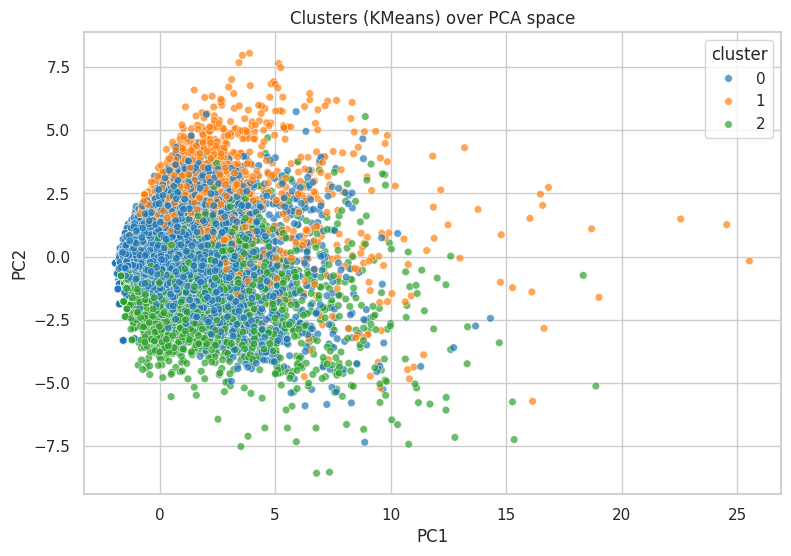

In [13]:
# Visualize clusters on PC1 vs PC2
plt.figure(figsize=(9,6))
sns.scatterplot(x=pc_df["PC1"], y=pc_df["PC2"], hue=df["cluster"], palette="tab10", s=30, alpha=0.7)
plt.title("Clusters (KMeans) over PCA space")
plt.show()


# **Cluster profiling and business interpretation**
We examine segment sizes and key metrics (brand_sum, purchase_diversity, category aggregates, gender distribution).


# **12. Profile clusters**


In [ ]:
cluster_profile = df.groupby("cluster").agg(
    customers=(id_col, "count"),
    avg_brand_sum=("brand_sum","mean"),
    median_brand_sum=("brand_sum","median"),
    avg_diversity=("purchase_diversity","mean")
).reset_index().sort_values("cluster")
display(cluster_profile)

# Category aggregates per cluster
cat_cols = [f"cat_{c}" for c in categories]
cluster_cat = df.groupby("cluster")[cat_cols].mean().round(2)
display(cluster_cat)

# Top brands per cluster (mean)
cluster_brand_means = df.groupby("cluster")[brand_cols].mean()
for cl in sorted(df["cluster"].unique()):
    print(f"\nTop brands cluster {cl}:")
    display(cluster_brand_means.loc[cl].sort_values(ascending=False).head(8))


# **Discriminant analysis (LDA) to interpret clusters**
We train a Linear Discriminant Analysis model to see which features discriminate clusters.
This helps produce simple linear combinations of features for explainability.


# **13. LDA using factor scores to predict cluster**


In [ ]:
X = df[cluster_features].values
y = df["cluster"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
print("LDA training score:", lda.score(X_train, y_train))
print("LDA test score:", lda.score(X_test, y_test))

# LDA coefficients (per discriminant)
coef = pd.DataFrame(lda.coef_, columns=cluster_features)
display(coef.round(3))


# **Canonical Correlation Analysis (CCA)**
We create two sensible variable groups from category aggregates (Electronics vs Apparel+Food) to explore relationships between product category preferences.


# **14. CCA on category aggregates**

 - Group A: Electronics
 - Group B: Apparel + Food (if present)


In [14]:
groupA = []
groupB = []
if "cat_Electronics" in df.columns:
    groupA = ["cat_Electronics"]
# put Apparel + Food into groupB
for cat in ["Apparel","Food"]:
    if f"cat_{cat}" in df.columns:
        groupB.append(f"cat_{cat}")

# If groups too small, fall back to two halves of brand categories
if len(groupA)==0 or len(groupB)==0:
    # split categories by alphabetical halves
    all_cat_cols = [c for c in df.columns if c.startswith("cat_")]
    mid = max(1, len(all_cat_cols)//2)
    groupA = all_cat_cols[:mid]
    groupB = all_cat_cols[mid:mid*2] if len(all_cat_cols) > mid else all_cat_cols[mid:]

print("CCA groupA:", groupA)
print("CCA groupB:", groupB)

if len(groupA)>0 and len(groupB)>0:
    X = StandardScaler().fit_transform(df[groupA].fillna(0))
    Y = StandardScaler().fit_transform(df[groupB].fillna(0))
    cca = CCA(n_components=1)
    cca.fit(X,Y)
    X_c, Y_c = cca.transform(X,Y)
    corr = np.corrcoef(X_c.T, Y_c.T)[0,1]
    print("Canonical correlation (1st component):", round(corr,4))
else:
    print("Insufficient category groups for CCA")


CCA groupA: ['cat_Electronics']
CCA groupB: ['cat_Apparel', 'cat_Food']
Canonical correlation (1st component): 0.3015


# **Hypothesis testing: Differences by Gender**
We test whether overall purchase behavior differs by gender using nonparametric tests (Mann–Whitney) on brand_sum and purchase_diversity. For multiple brand-level tests, we control false discovery.


In [15]:
# 15. Gender comparisons
if gender_col and gender_col in df.columns:
    genders = df[gender_col].dropna().unique()
    print("Detected genders:", genders)
    if len(genders)==2:
        g0, g1 = genders[:2]
        a = df[df[gender_col]==g0]["brand_sum"]
        b = df[df[gender_col]==g1]["brand_sum"]
        stat, p = stats.mannwhitneyu(a,b, alternative="two-sided")
        print(f"Mann-Whitney brand_sum {g0} vs {g1}: U={stat}, p={p:.4g}")
        # diversity
        stat2, p2 = stats.mannwhitneyu(df[df[gender_col]==g0]["purchase_diversity"], df[df[gender_col]==g1]["purchase_diversity"])
        print(f"Mann-Whitney diversity: U={stat2}, p={p2:.4g}")
    else:
        print("More than 2 gender categories; consider Kruskal-Wallis across groups.")
else:
    print("Gender column not available or contains too many missing values.")


Detected genders: ['M' 'F']
Mann-Whitney brand_sum M vs F: U=46326580.5, p=4.711e-108
Mann-Whitney diversity: U=42533277.5, p=1.729e-193


# **Business action plan per cluster**
We produce concrete, prioritized actions for each cluster based on profiling above: acquisition, cross-sell, retention, premium offers, and reactivation strategies.


# **16. Build action plan heuristically**


In [16]:
cluster_profile = df.groupby("cluster").agg(
    customers=(id_col,"count"),
    avg_brand_sum=("brand_sum","mean"),
    avg_diversity=("purchase_diversity","mean")
).reset_index()

plans = {}
for _, row in cluster_profile.iterrows():
    cl = int(row["cluster"])
    customers = int(row["customers"])
    avg_sum = row["avg_brand_sum"]
    avg_div = row["avg_diversity"]
    if avg_sum > df["brand_sum"].quantile(0.75):
        plan = [
            "High-value: prioritize premium retention offers, VIP program",
            "Cross-sell complementary products (use top brand affinities)",
            "Referral programs and personalized bundles"
        ]
    elif avg_div < df["purchase_diversity"].quantile(0.25):
        plan = [
            "Low diversity: run discovery campaigns, product recommendations to expand basket",
            "Use low-cost sampling or small discounts to try adjacent categories"
        ]
    else:
        plan = [
            "Consider frequency incentives (loyalty points), A/B test promo elasticities",
            "Use email flows and targeted remarketing"
        ]
    plans[cl] = {"profile": row.to_dict(), "recommendations": plan}

# Display
for cl in sorted(plans.keys()):
    print(f"\nCluster {cl} — profile: {plans[cl]['profile']}")
    print("Recommendations:")
    for r in plans[cl]["recommendations"]:
        print(" -", r)



Cluster 0 — profile: {'cluster': 0.0, 'customers': 24008.0, 'avg_brand_sum': 5.714303565478174, 'avg_diversity': 3.6395784738420525}
Recommendations:
 - Consider frequency incentives (loyalty points), A/B test promo elasticities
 - Use email flows and targeted remarketing

Cluster 1 — profile: {'cluster': 1.0, 'customers': 1777.0, 'avg_brand_sum': 12.773213280810355, 'avg_diversity': 7.613393359594823}
Recommendations:
 - High-value: prioritize premium retention offers, VIP program
 - Cross-sell complementary products (use top brand affinities)
 - Referral programs and personalized bundles

Cluster 2 — profile: {'cluster': 2.0, 'customers': 4215.0, 'avg_brand_sum': 10.974139976275207, 'avg_diversity': 6.224199288256227}
Recommendations:
 - High-value: prioritize premium retention offers, VIP program
 - Cross-sell complementary products (use top brand affinities)
 - Referral programs and personalized bundles


# **Reporting: Export cluster assignments and summary**
We can export cluster labels and summary to CSV for dashboarding or further modeling.


# **17. Export results**


In [17]:
out = df[[id_col, gender_col, orders_col, "brand_sum", "purchase_diversity", "cluster"] + [f"cat_{c}" for c in categories] + factor_cols]
out.to_csv("customer_segments_and_features.csv", index=False)
print("Wrote customer_segments_and_features.csv (first rows):")
display(out.head())


Wrote customer_segments_and_features.csv (first rows):


,Cust_ID,Gender,Orders,brand_sum,purchase_diversity,cluster,cat_Apparel,cat_Electronics,cat_Food,cat_Other,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
0,1,M,7,2,1,0,2,0,0,0,-0.310626,-0.228956,-0.146567,-0.730950,0.844661,-0.318399,-0.455363,-0.442407,-0.235447,-0.371862
1,2,F,0,18,8,0,8,4,1,5,0.484568,-0.515715,-0.545781,1.402700,0.489045,-0.056741,0.815226,-0.705647,0.864435,0.535578
2,3,M,7,5,4,2,0,1,1,3,-0.302880,2.234227,-0.114937,-0.454499,0.190503,-0.262260,0.199136,-0.266800,-0.300940,0.553208
3,4,F,0,2,2,0,1,0,0,1,-0.360300,-0.278223,-0.218694,-0.352351,-0.248450,-0.364248,0.004602,-0.392648,0.330860,-0.070413
4,5,NaN,10,16,9,2,3,1,2,10,3.736221,0.861055,-0.287222,0.514697,-0.841245,0.030757,0.630550,0.030849,-0.702389,-0.503086
